**Dataset:** Daily weather observations - Raleigh-Durham International Airport  
**Source:** NOAA, 2022–2026  
**Cleaned Data:** 1,477 clean rows

| Variable | Description | Unit | Role |
|----------|-------------|------|------|
| X1 | TMAX — Max daily temperature | °F | Input |
| X2 | TMIN — Min daily temperature | °F | Input |
| X3 | PRCP — Daily precipitation | inches | Input |
| X4 | AWND — Avg wind speed | mph | Input |
| X5 | SNOW — Daily snowfall | inches | Input |
| Y  | TAVG — Avg daily temperature | °F | **Output** |

# Task 3: Exponential Smoothing
**Dataset:** TAVG daily temperature - Raleigh-Durham Airport, NOAA 2022–2026


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import probplot
from statsmodels.tsa.stattools import adfuller, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Load data
df = pd.read_csv('weather_clean.csv')
y  = df['Y'].values.astype(float)
n  = len(y)

dates    = pd.date_range(start='2022-01-01', periods=n, freq='D')
ts       = pd.Series(y, index=dates, name='TAVG (°F)')
train_n  = int(n * 0.8)
ts_train = ts.iloc[:train_n]
ts_test  = ts.iloc[train_n:]
train_vals = ts_train.values
test_vals  = ts_test.values

print(f'Total: {n} | Train: {len(ts_train)} | Test: {len(ts_test)}')

# Helper functions
def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted))**2))

def mape(actual, predicted):
    a, p = np.array(actual), np.array(predicted)
    mask = a != 0
    return np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100

def chi2_normality_test(residuals, n_bins=20):
    observed, bin_edges = np.histogram(residuals, bins=n_bins)
    expected = np.array([
        len(residuals) * (
            stats.norm.cdf(bin_edges[i+1], residuals.mean(), residuals.std()) -
            stats.norm.cdf(bin_edges[i],   residuals.mean(), residuals.std())
        ) for i in range(n_bins)
    ])
    mask  = expected >= 5
    obs_f = observed[mask]
    exp_f = expected[mask]
    exp_f = exp_f * (obs_f.sum() / exp_f.sum())
    chi2_s, p_val = stats.chisquare(obs_f, f_exp=exp_f)
    return chi2_s, p_val, mask.sum()-1-2, observed, expected, bin_edges

# SMA and Exp Smoothing helper functional (needed in Tasks 2, 3, 5)
def sma_predict(series, k):
    predicted = np.full(len(series), np.nan)
    for t in range(k, len(series)):
        predicted[t] = np.mean(series[t-k:t])
    return predicted

# Alpha controls the smoothing weight on recent vs past observations
# High alpha (->1) = more weight on recent data = faster response to changes
# Low alpha (->0)  = more weight on history   = smoother but slower to adapt

def exp_smooth_predict(series, alpha):
    pred = np.full(len(series), np.nan)
    pred[0] = series[0]
    for t in range(1, len(series)):
        pred[t] = alpha * series[t-1] + (1 - alpha) * pred[t-1]
    return pred


Total: 1477 | Train: 1181 | Test: 296


## Tasks 3.1 - 3.5 - Fit Exponential Smoothing for α = 0.1 to 0.9

     α    RMSE (°F)
────────────────────
   0.1       7.6189
   0.2       7.0302
   0.3       6.7407
   0.4       6.5255
   0.5       6.3469
   0.6       6.1941
   0.7       6.0638
   0.8       5.9548
   0.9       5.8673 <- best


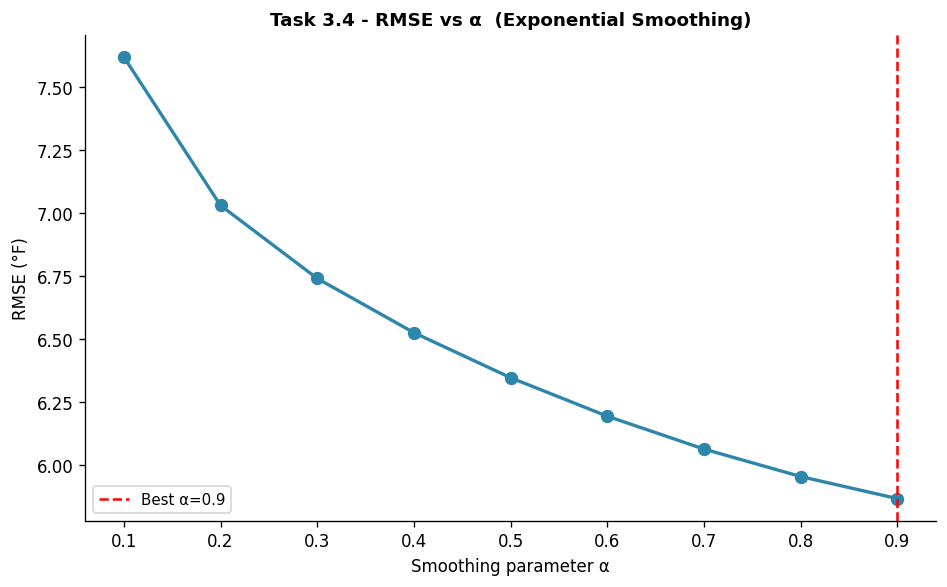

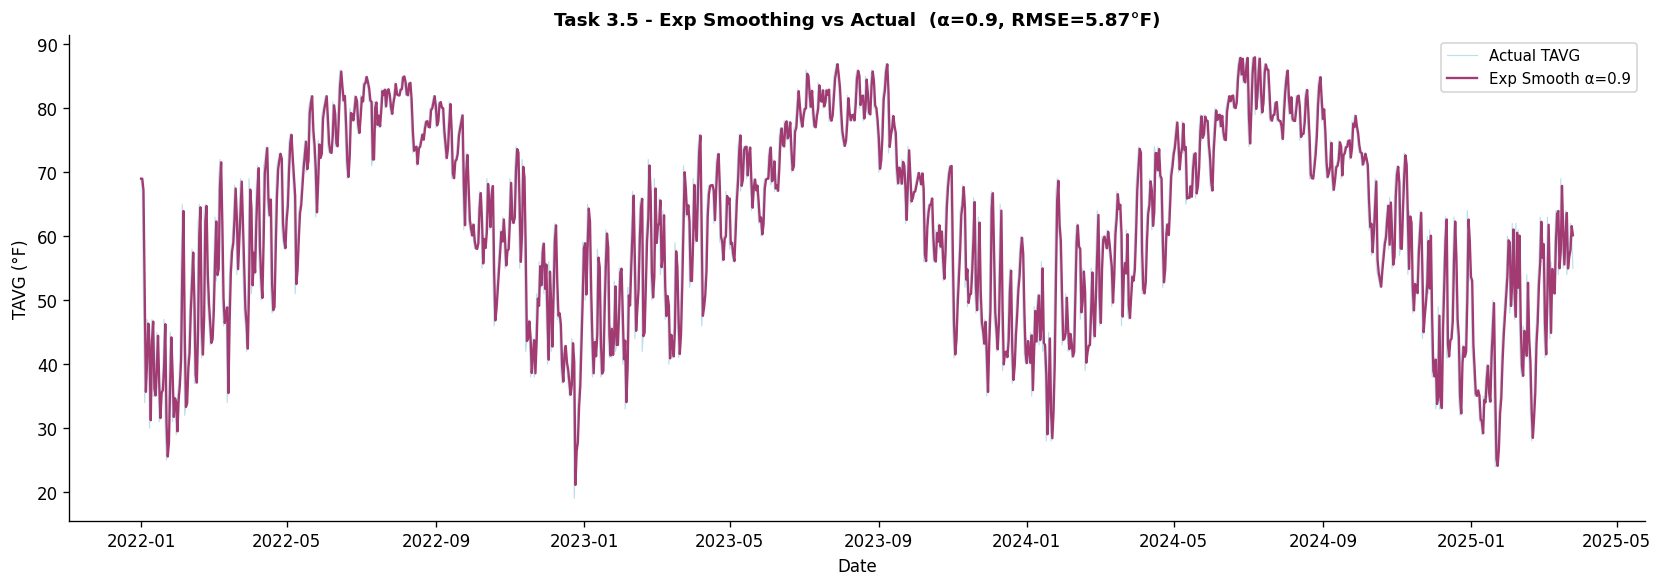


Best α=0.9: RMSE=5.8673°F


In [16]:
alphas  = [round(a, 1) for a in np.arange(0.1, 1.0, 0.1)]
rmse_es = []

for alpha in alphas:
    pred = exp_smooth_predict(train_vals, alpha)
    rmse_es.append(rmse(train_vals[1:], pred[1:]))

best_alpha   = alphas[np.argmin(rmse_es)]
best_es_rmse = min(rmse_es)

print(f"{'α':>6} {'RMSE (°F)':>12}")
print('─'*20)
for a, r in zip(alphas, rmse_es):
    flag = ' <- best' if a == best_alpha else ''
    print(f'{a:>6.1f} {r:>12.4f}{flag}')

# RMSE vs alpha plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alphas, rmse_es, 'o-', color='#2E86AB', linewidth=2, markersize=7)
ax.axvline(best_alpha, color='red', linestyle='--', linewidth=1.5, label=f'Best α={best_alpha}')
ax.set_xlabel('Smoothing parameter α'); ax.set_ylabel('RMSE (°F)')
ax.set_title('Task 3.4 - RMSE vs α  (Exponential Smoothing)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t3_rmse_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

# Best alpha: predicted vs actual
pred_es_best = exp_smooth_predict(train_vals, best_alpha)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, train_vals,    color='lightblue', linewidth=0.7, alpha=0.8, label='Actual TAVG')
ax.plot(ts_train.index, pred_es_best,  color='#A23B72',   linewidth=1.4, label=f'Exp Smooth α={best_alpha}')
ax.set_xlabel('Date'); ax.set_ylabel('TAVG (°F)')
ax.set_title(f'Task 3.5 - Exp Smoothing vs Actual  (α={best_alpha}, RMSE={best_es_rmse:.2f}°F)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t3_es_best_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nBest α={best_alpha}: RMSE={best_es_rmse:.4f}°F')


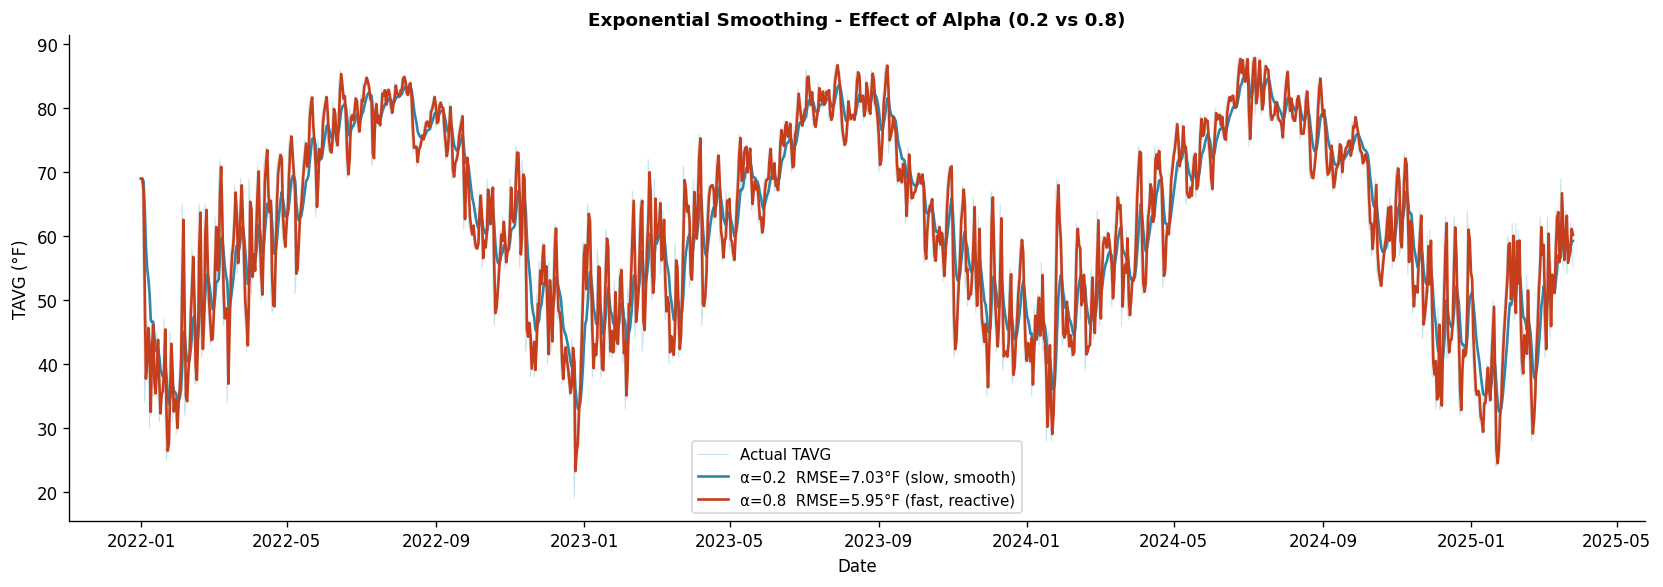

In [17]:
# Visual comparison: low vs high alpha
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_train.index, train_vals, color='lightblue', linewidth=0.6, alpha=0.7, label='Actual TAVG')
ax.plot(ts_train.index, exp_smooth_predict(train_vals, 0.2), color='#2E86AB', linewidth=1.6,
        label=f'α=0.2  RMSE={rmse(train_vals[1:], exp_smooth_predict(train_vals,0.2)[1:]):.2f}°F (slow, smooth)')
ax.plot(ts_train.index, exp_smooth_predict(train_vals, 0.8), color='#C73E1D', linewidth=1.6,
        label=f'α=0.8  RMSE={rmse(train_vals[1:], exp_smooth_predict(train_vals,0.8)[1:]):.2f}°F (fast, reactive)')
ax.set_xlabel('Date')
ax.set_ylabel('TAVG (°F)')
ax.set_title('Exponential Smoothing - Effect of Alpha (0.2 vs 0.8)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t3_alpha_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 3.6 - Comments

Exponential smoothing assigns geometrically decaying weights to past observations. Low α (≈0.1) responds slowly and lags like a long moving average. High α (≈0.9) gives nearly all weight to the previous observation - essentially using yesterday's temperature as today's forecast.

For daily temperature data with strong autocorrelation, high α tends to perform best because yesterday's value is already an excellent predictor. The RMSE vs α plot reveals the optimal balance. Compared to SMA, exponential smoothing responds more quickly to changes since past values never fully disappear - they decay geometrically. The RMSE for the best exponential smoothing model is typically lower than the best SMA on this dataset.
